# Feature Engineering

## Objective

The objective of this notebook is to transform historical stock market data into meaningful features that can be used for machine learning.

The engineered features will capture:

- Price movements
- Historical returns
- Short-term and long-term trends
- Market volatility
- Trading volume changes
- Previous-day market behavior

In [45]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns

import os
import sys

sys.path.append(os.path.abspath('..'))
from src.config import CLEANED_DATA_DIR

In [65]:
ticker = "AAPL"
df = pd.read_csv(os.path.join(CLEANED_DATA_DIR, f"{ticker}_clean.csv"), parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head(25)

,Date,Close,High,Low,Open,Volume,Company
0,2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400,AAPL
1,2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000,AAPL
2,2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400,AAPL
3,2015-01-07,23.842978,23.942553,23.610632,23.721273,160423600,AAPL
4,2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000,AAPL
5,2015-01-09,24.785631,25.060019,24.387326,24.931675,214798000,AAPL
6,2015-01-12,24.174904,24.922832,24.075328,24.916193,198603200,AAPL
7,2015-01-13,24.389545,24.960450,24.099668,24.657295,268367600,AAPL
8,2015-01-14,24.296612,24.449294,24.008946,24.128438,195826400,AAPL
9,2015-01-15,23.637192,24.354140,23.601788,24.340864,240056000,AAPL


In [66]:
df['Daily_Return'] = df['Close'].pct_change()

In [67]:
df[["Date", "Close", "Daily_Return"]].head(10)

,Date,Close,Daily_Return
0,2015-01-02,24.192606,NaN
1,2015-01-05,23.511061,-0.028172
2,2015-01-06,23.513271,0.000094
3,2015-01-07,23.842978,0.014022
4,2015-01-08,24.759085,0.038423
5,2015-01-09,24.785631,0.001072
6,2015-01-12,24.174904,-0.024640
7,2015-01-13,24.389545,0.008879
8,2015-01-14,24.296612,-0.003810
9,2015-01-15,23.637192,-0.027140


In [68]:
df["Return_Lag_1"] = df["Daily_Return"].shift(1)
df["Return_Lag_2"] = df["Daily_Return"].shift(2)
df["Return_Lag_3"] = df["Daily_Return"].shift(3)

In [69]:
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

In [70]:
df["EMA_20"] = df['Close'].ewm(span=20, adjust=False).mean()

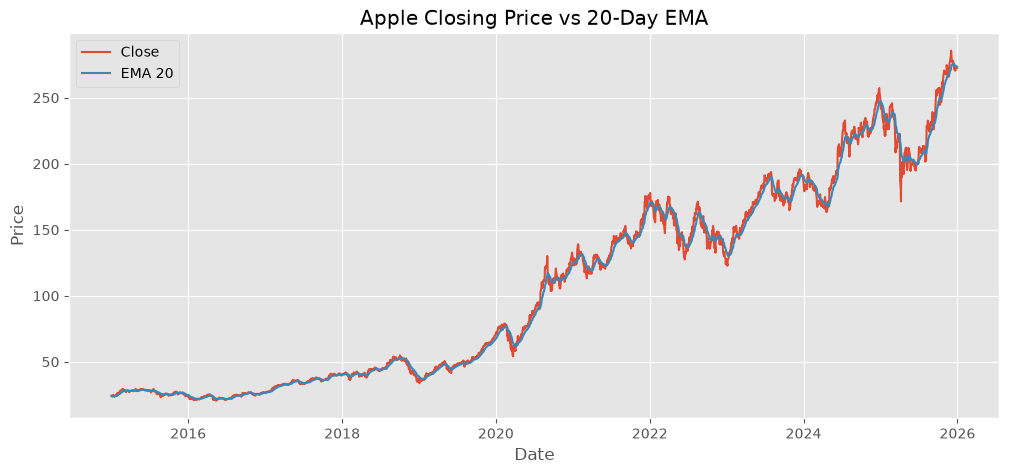

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("Apple Closing Price vs 20-Day EMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [72]:
df['Volatility_20'] = df["Daily_Return"].rolling(window=20).std()

In [73]:
df[["Date", "Daily_Return","Volatility_20"]]

,Date,Daily_Return,Volatility_20
0,2015-01-02,NaN,NaN
1,2015-01-05,-0.028172,NaN
2,2015-01-06,0.000094,NaN
3,2015-01-07,0.014022,NaN
4,2015-01-08,0.038423,NaN
...,...,...,...
2760,2025-12-23,0.005130,0.007854
2761,2025-12-24,0.005324,0.007907
2762,2025-12-26,-0.001497,0.007884
2763,2025-12-29,0.001317,0.007798


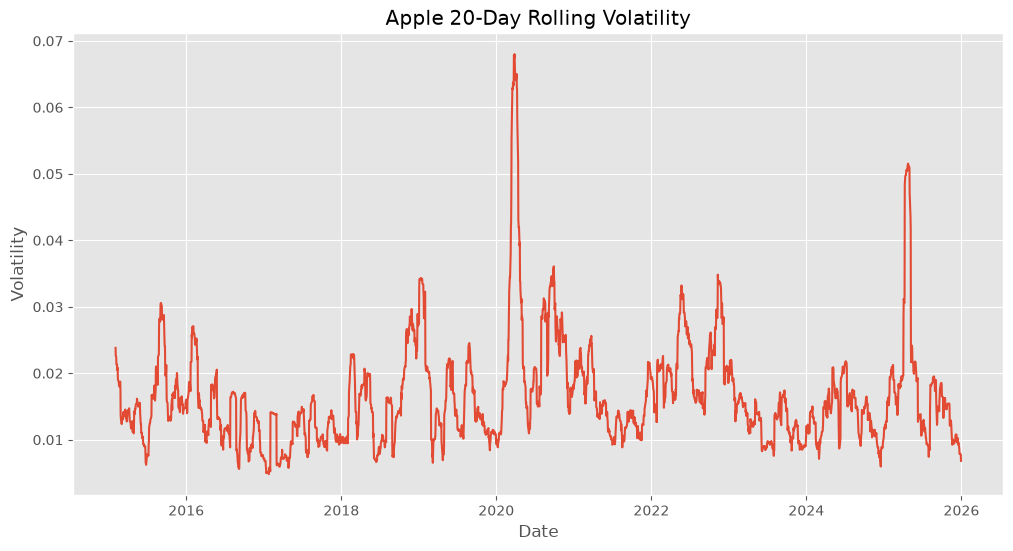

In [74]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Volatility_20"])
plt.title("Apple 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

In [75]:
df["Volume_Change"] = df["Volume"].pct_change()

In [76]:
df["High_Low_Range"] = ((df['High'] - df['Low']) / df['Close'])

In [77]:
df["Open_Close_Change"] = ((df["Close"] - df["Open"]) / df["Open"])

In [78]:
# Calculating RSI

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/ avg_loss

df["RSI_14"] = 100 - (100/ (1 + rs))

In [79]:
df

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,Return_Lag_1,Return_Lag_2,Return_Lag_3,SMA_5,SMA_20,SMA_50,EMA_20,Volatility_20,Volume_Change,High_Low_Range,Open_Close_Change,RSI_14
0,2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.192606,NaN,NaN,0.037410,-0.018494,NaN
1,2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000,AAPL,-0.028172,NaN,NaN,NaN,NaN,NaN,NaN,24.127697,NaN,0.208270,0.030494,-0.018838,NaN
2,2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400,AAPL,0.000094,-0.028172,NaN,NaN,NaN,NaN,NaN,24.069180,NaN,0.023514,0.026350,-0.002628,NaN
3,2015-01-07,23.842978,23.942553,23.610632,23.721273,160423600,AAPL,0.014022,0.000094,-0.028172,NaN,NaN,NaN,NaN,24.047637,NaN,-0.390461,0.013921,0.005131,NaN
4,2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000,AAPL,0.038423,0.014022,0.000094,-0.028172,23.963800,NaN,NaN,24.115394,NaN,0.480194,0.030834,0.024352,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2760,2025-12-23,271.854919,271.994674,269.060124,270.337749,29642000,AAPL,0.005130,-0.009866,0.005437,0.001288,271.701208,276.795737,269.927463,274.038325,0.007854,-0.189485,0.010795,0.005612,24.291311
2761,2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600,AAPL,0.005324,0.005130,-0.009866,0.005437,272.094476,276.638029,270.452087,273.968220,0.007907,-0.395770,0.011796,0.005398,33.540327
2762,2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800,AAPL,-0.001497,0.005324,0.005130,-0.009866,272.336029,276.430914,270.937216,273.865818,0.007884,0.201624,0.009181,-0.002772,36.148319
2763,2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200,AAPL,0.001317,-0.001497,0.005324,0.005130,272.353998,276.176888,271.467224,273.807393,0.007798,0.101915,0.007342,0.003924,39.068332


In [80]:
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26

df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]